In [38]:
import pandas as pd

file_path = "data_scaling_skewed_data.csv"
df = pd.read_csv(file_path)

df = df.dropna(subset=["Internet_Usage_Hours", "Exam_Score"]).reset_index(drop=True)

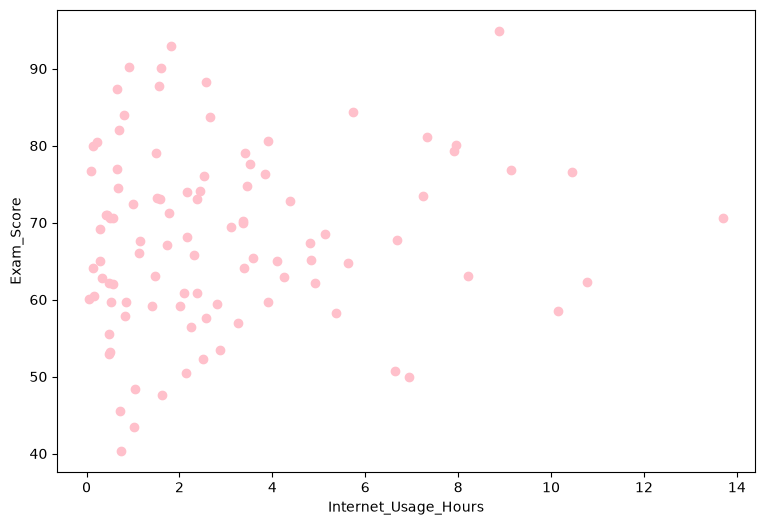

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6))
plt.scatter(df["Internet_Usage_Hours"], df["Exam_Score"], color="pink")
plt.xlabel("Internet_Usage_Hours")
plt.ylabel("Exam_Score")
plt.show()

In [40]:
import numpy as np

def calc_reg(x, y):
    x = np.asarray(x).flatten()
    y = np.asarray(y).flatten()

    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    Nr = 0
    Dr = 0
    for i in range(n):
        Nr += (x[i] - x_mean) * (y[i] - y_mean)
        Dr += (x[i] - x_mean) ** 2

    m = Nr / Dr
    b = y_mean - m * x_mean
    y_pred = m * x + b

    print("slope (m):", m)
    print("Y-intercept (b):", b)
    return m, b, y_pred

In [41]:
x= df[["Internet_Usage_Hours"]].values
x

array([[ 5.13],
       [10.14],
       [ 6.63],
       [ 0.99],
       [ 2.1 ],
       [ 0.48],
       [10.78],
       [ 3.26],
       [ 0.91],
       [ 3.9 ],
       [ 3.37],
       [ 1.55],
       [ 0.42],
       [ 3.9 ],
       [ 2.57],
       [ 2.57],
       [ 6.69],
       [ 2.81],
       [ 2.88],
       [ 7.32],
       [ 1.81],
       [ 0.5 ],
       [ 0.1 ],
       [ 4.92],
       [ 3.39],
       [ 4.26],
       [ 0.84],
       [ 0.51],
       [ 0.05],
       [ 1.51],
       [ 3.12],
       [ 1.74],
       [ 2.01],
       [ 8.21],
       [ 1.5 ],
       [ 2.53],
       [ 5.36],
       [ 1.77],
       [ 3.41],
       [ 6.94],
       [10.45],
       [ 0.56],
       [ 9.14],
       [ 2.37],
       [ 1.05],
       [ 2.15],
       [13.7 ],
       [ 2.37],
       [ 1.4 ],
       [ 3.51],
       [ 0.28],
       [ 0.48],
       [ 0.48],
       [ 0.58],
       [ 0.52],
       [ 3.58],
       [ 0.7 ],
       [ 1.48],
       [ 7.95],
       [ 2.25],
       [ 3.85],
       [ 0.66],
       [

In [42]:
y = df["Exam_Score"].values
y

array([68.46, 58.53, 50.72, 72.44, 60.92, 52.93, 62.24, 57.02, 90.25,
       80.58, 69.9 , 87.76, 70.93, 59.66, 88.28, 57.55, 67.72, 59.49,
       53.41, 81.11, 92.91, 53.22, 76.76, 62.19, 64.15, 62.89, 59.63,
       70.58, 60.03, 73.25, 69.4 , 67.13, 59.11, 63.08, 79.06, 76.01,
       58.27, 71.19, 79.02, 49.97, 76.52, 62.05, 76.85, 60.84, 48.34,
       50.47, 70.58, 73.12, 59.15, 77.66, 69.21, 55.47, 62.18, 70.57,
       59.68, 65.39, 82.08, 63.08, 80.03, 56.44, 76.36, 87.3 , 40.34,
       60.44, 76.92, 67.56, 74.45, 62.75, 71.04, 68.13, 84.01, 73.05,
       74.05, 65.06, 64.15, 64.81, 74.73, 64.95, 73.48, 94.9 , 80.45,
       66.09, 84.41, 65.1 , 45.54, 57.9 , 47.55, 65.78, 70.22, 90.12,
       73.92, 67.37, 79.95, 43.47, 72.83, 79.25, 52.26, 83.73])

In [43]:
import numpy as np
m,b,y_pred = calc_reg(x,y)

slope (m): 0.44162104046650946
Y-intercept (b): 66.66594171606667


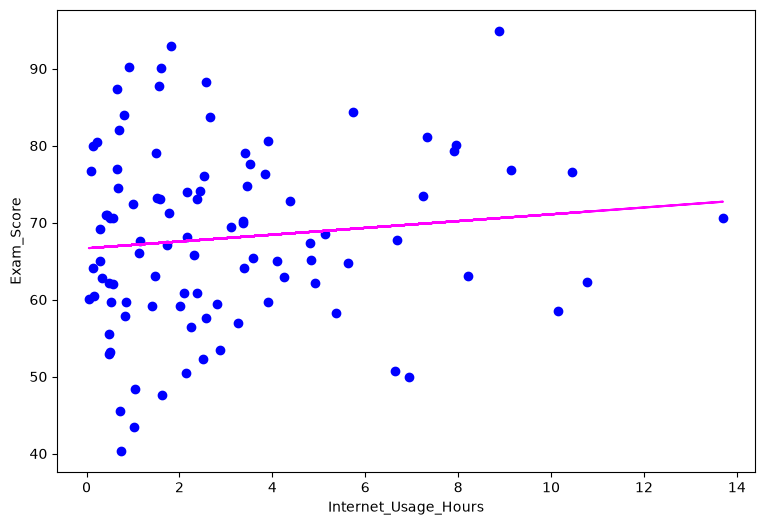

In [44]:
import matplotlib.pyplot as plt
from matplotlib.figure import SubFigure
import seaborn as sns
plt.figure(figsize=(9,6))
plt.scatter(df["Internet_Usage_Hours"],df["Exam_Score"],color="blue")
plt.plot(df["Internet_Usage_Hours"],y_pred,color="magenta")
plt.xlabel("Internet_Usage_Hours")
plt.ylabel("Exam_Score")
plt.show()

In [45]:
x= df[["Internet_Usage_Hours"]].values
y= df["Exam_Score"].values
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)


In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.24]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,66.62
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[23.31]


In [47]:
model.coef_[0]

np.float64(0.23600845162084647)

In [48]:
model.intercept_

np.float64(66.62337075464187)

In [49]:
y_pred = model.predict(x_test)
y_pred

array([67.62876676, 69.85668654, 68.71912581, 66.79093676, 67.78453234,
       66.89242039, 67.05054605, 66.98918385, 67.97805927, 66.7224943 ,
       66.86409938, 68.56100014, 66.82161785, 66.73665481, 67.1189885 ,
       66.65877202, 67.17091036, 66.77913633, 67.42815957, 67.00334436])

In [50]:
compare = pd.DataFrame({
    "Actual":y_test,
    "Predict":y_pred
})

In [51]:
compare

,Actual,Predict
0,62.89,67.628767
1,70.58,69.856687
2,94.90,68.719126
3,45.54,66.790937
4,62.19,67.784532
5,67.56,66.892420
6,92.91,67.050546
7,87.76,66.989184
8,84.41,67.978059
9,70.93,66.722494
